<a href="https://colab.research.google.com/github/Romfff/ThucHanhDeepLearning/blob/main/Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- THÔNG TIN DỮ LIỆU BAN ĐẦU ---
Kích thước file gốc: 303 hàng, 14 cột

5 hàng đầu tiên:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0



Số lượng giá trị thiếu ở mỗi cột ban đầu:
age          8
sex          8
cp          11
trestbps     8
chol        10
fbs          8
restecg      8
thalach     12
exang        8
oldpeak      8
slope        8
ca          12
thal         8
state       10
dtype: int64

Số lượng hàng trùng lặp phát hiện: 7
-> Đã xóa các hàng trùng lặp thành công.

--- XỬ LÝ HOÀN TẤT ---
Kích thước dữ liệu sau khi xử lý: 296 hàng, 14 cột

--- BẢNG SO SÁNH THỐNG KÊ (MỘT SỐ CỘT SỐ NỔI BẬT) ---

[Thuộc tính: age]


,Ban đầu (Original),Sau xử lý (Processed)
count,295.000000,2.960000e+02
mean,54.362712,2.010404e-16
std,9.040007,1.001693e+00
min,29.000000,-2.815349e+00
25%,47.500000,-7.342107e-01
50%,55.000000,7.049623e-02
75%,61.000000,7.364606e-01
max,77.000000,2.512366e+00



[Thuộc tính: trestbps]


,Ban đầu (Original),Sau xử lý (Processed)
count,295.000000,2.960000e+02
mean,131.389831,3.255654e-16
std,17.271361,1.001693e+00
min,94.000000,-2.171900e+00
25%,120.000000,-6.614226e-01
50%,130.000000,-8.046982e-02
75%,140.000000,5.004830e-01
max,200.000000,3.986200e+00



[Thuộc tính: chol]


,Ban đầu (Original),Sau xử lý (Processed)
count,293.000000,2.960000e+02
mean,247.225256,1.305262e-16
std,51.819006,1.001693e+00
min,126.000000,-2.354216e+00
25%,211.000000,-6.882079e-01
50%,242.000000,-1.004908e-01
75%,276.000000,5.455122e-01
max,564.000000,6.155538e+00


/tmp/ipykernel_4548/3426340640.py:83: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_original['trestbps'], ax=axes[0, 0], color='red', label='Ban đầu', shade=True)
/tmp/ipykernel_4548/3426340640.py:84: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_processed['trestbps'], ax=axes[0, 0], color='green', label='Sau xử lý (Chuẩn hóa)', shade=True)
/tmp/ipykernel_4548/3426340640.py:90: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_original['chol'], ax=axes[0, 1], color='red', label='Ban đầu', shade=True)
/tmp/ipykernel_4548/3426340640.py:91: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=Tr

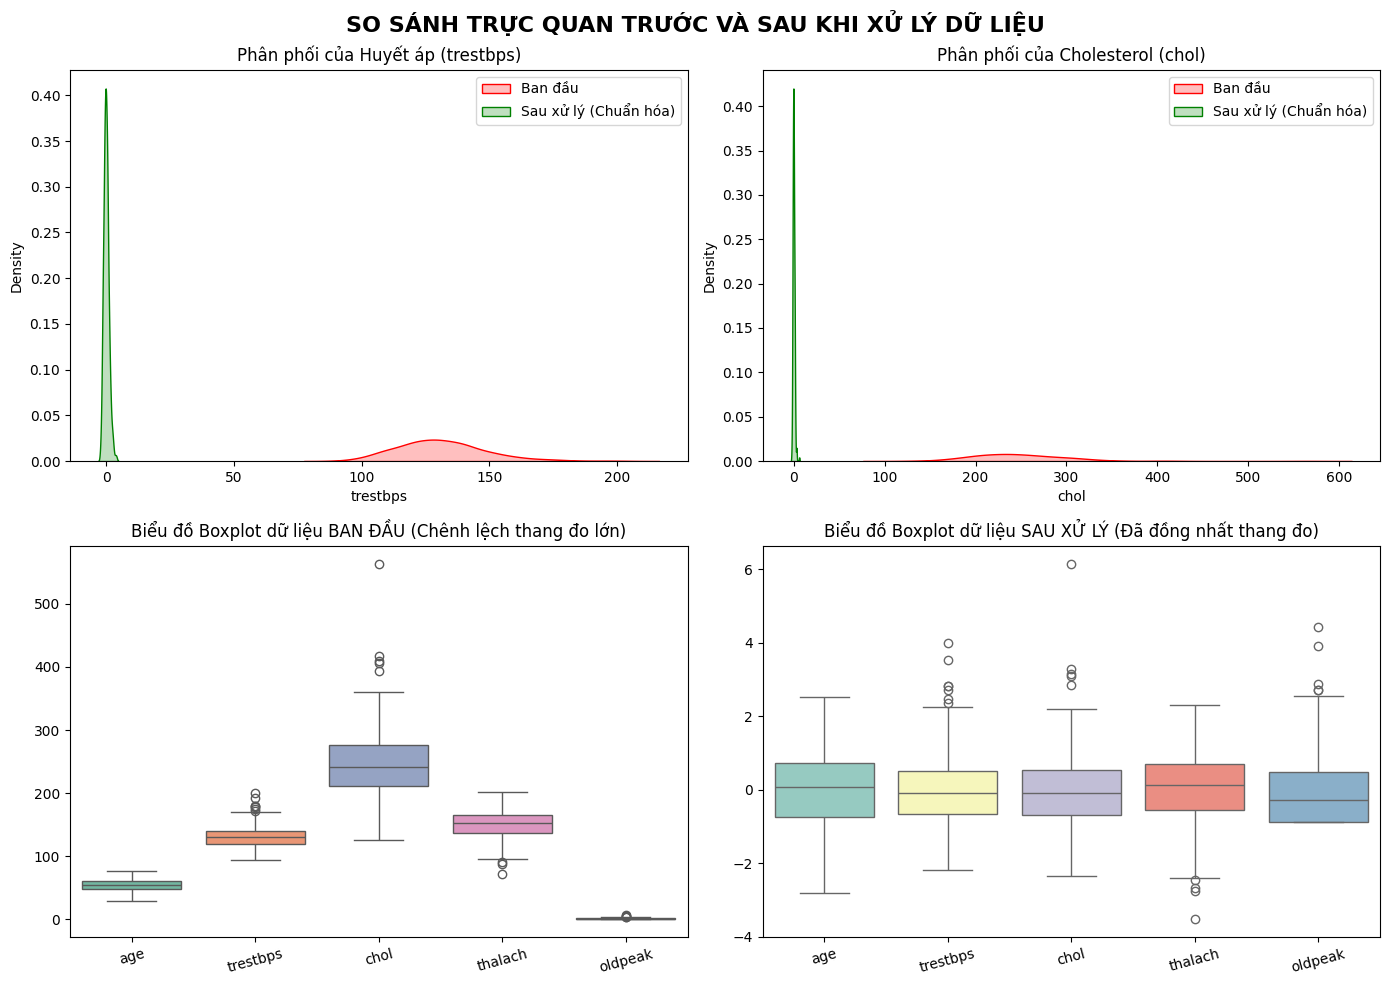

In [1]:
# ==========================================
# 1. KHAI BÁO THƯ VIỆN & TẢI DỮ LIỆU
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Đường dẫn file excel trực tiếp từ GitHub
url = "https://github.com/Romfff/ThucHanhDeepLearning/raw/main/Data/heart_disease_dataset.xlsx"

# Đọc file dữ liệu (Do là file .xlsx nên pandas sẽ dùng thư viện openpyxl tự động)
df_original = pd.read_excel(url)

print("--- THÔNG TIN DỮ LIỆU BAN ĐẦU ---")
print(f"Kích thước file gốc: {df_original.shape[0]} hàng, {df_original.shape[1]} cột")
print("\n5 hàng đầu tiên:")
display(df_original.head())

# Tạo một bản sao để tiến hành xử lý dữ liệu
df_processed = df_original.copy()

# ==========================================
# 2. XỬ LÝ DỮ LIỆU (PREPROCESSING)
# ==========================================

# Bước 2.1: Xử lý giá trị bị thiếu (Missing Values)
# Kiểm tra số lượng ô trống ở mỗi cột
missing_info = df_processed.isnull().sum()
print("\nSố lượng giá trị thiếu ở mỗi cột ban đầu:")
print(missing_info[missing_info > 0] if missing_info.sum() > 0 else "Không có giá trị thiếu.")

# Điền giá trị thiếu (Nếu có)
# - Cột số liên tục: Điền bằng giá trị trung vị (Median)
# - Cột phân loại: Điền bằng giá trị xuất hiện nhiều nhất (Mode)
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['int64', 'float64']:
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())
        else:
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

# Bước 2.2: Xử lý dữ liệu trùng lặp (Duplicate Rows)
duplicate_count = df_processed.duplicated().sum()
print(f"\nSố lượng hàng trùng lặp phát hiện: {duplicate_count}")
if duplicate_count > 0:
    df_processed = df_processed.drop_duplicates().reset_index(drop=True)
    print("-> Đã xóa các hàng trùng lặp thành công.")

# Bước 2.3: Chuẩn hóa dữ liệu số (Feature Scaling)
# Đối với tập dữ liệu Tim mạch, các thuộc tính số thường là: age, trestbps, chol, thalach, oldpeak
# Chúng ta sẽ dùng StandardScaler để đưa chúng về phân phối chuẩn (Mean=0, Std=1)
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
# Lọc lại các cột thực tế có tồn tại trong dữ liệu của bạn để tránh lỗi tên cột
numeric_cols = [col for col in numeric_cols if col in df_processed.columns]

scaler = StandardScaler()
df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])

print("\n--- XỬ LÝ HOÀN TẤT ---")
print(f"Kích thước dữ liệu sau khi xử lý: {df_processed.shape[0]} hàng, {df_processed.shape[1]} cột")

# ==========================================
# 3. SO SÁNH DỮ LIỆU TRƯỚC VÀ SAU KHI XỬ LÝ
# ==========================================

print("\n--- BẢNG SO SÁNH THỐNG KÊ (MỘT SỐ CỘT SỐ NỔI BẬT) ---")
for col in numeric_cols[:3]: # Lấy ví dụ 3 cột đầu tiên để so sánh
    print(f"\n[Thuộc tính: {col}]")
    compare_df = pd.DataFrame({
        'Ban đầu (Original)': df_original[col].describe(),
        'Sau xử lý (Processed)': df_processed[col].describe()
    })
    display(compare_df)

# Vẽ biểu đồ so sánh trực quan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SO SÁNH TRỰC QUAN TRƯỚC VÀ SAU KHI XỬ LÝ DỮ LIỆU', fontsize=16, fontweight='bold')

# 1. So sánh phân phối của Huyết áp (trestbps) nếu có
if 'trestbps' in df_original.columns:
    sns.kdeplot(df_original['trestbps'], ax=axes[0, 0], color='red', label='Ban đầu', shade=True)
    sns.kdeplot(df_processed['trestbps'], ax=axes[0, 0], color='green', label='Sau xử lý (Chuẩn hóa)', shade=True)
    axes[0, 0].set_title('Phân phối của Huyết áp (trestbps)')
    axes[0, 0].legend()

# 2. So sánh phân phối của Cholesterol (chol) nếu có
if 'chol' in df_original.columns:
    sns.kdeplot(df_original['chol'], ax=axes[0, 1], color='red', label='Ban đầu', shade=True)
    sns.kdeplot(df_processed['chol'], ax=axes[0, 1], color='green', label='Sau xử lý (Chuẩn hóa)', shade=True)
    axes[0, 1].set_title('Phân phối của Cholesterol (chol)')
    axes[0, 1].legend()

# 3. Biểu đồ Boxplot xem phân bố tổng thể dữ liệu số Ban đầu
sns.boxplot(data=df_original[numeric_cols], ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Biểu đồ Boxplot dữ liệu BAN ĐẦU (Chênh lệch thang đo lớn)')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15)

# 4. Biểu đồ Boxplot xem phân bố tổng thể dữ liệu số Sau khi chuẩn hóa
sns.boxplot(data=df_processed[numeric_cols], ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Biểu đồ Boxplot dữ liệu SAU XỬ LÝ (Đã đồng nhất thang đo)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()